# Notebook 02: Multiple Quantiles and the Quantile Process

## Learning Objectives

By the end of this notebook, you will be able to:

1. Estimate the complete quantile process β(τ) for all τ
2. Visualize heterogeneity of effects across the distribution
3. Test equality of coefficients between quantiles (inter-quantile tests)
4. Identify patterns in distributional effects
5. Detect and interpret quantile crossing
6. Make simultaneous inference across multiple quantiles

## Duration
120 minutes

## Prerequisites
- Notebook 01 (Quantile Regression Fundamentals)
- Understanding of hypothesis testing

## Dataset
Card Education dataset: ~3,000 observations on wages, education, and demographics.  
Inspired by Card (1995), *Using Geographic Variation in College Proximity to Estimate the Return to Schooling*.

In [1]:
# Standard libraries
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# Statistical libraries
from scipy import stats

# PanelBox imports
from panelbox import PooledOLS
from panelbox.models.quantile import PooledQuantile

# Visualization configuration
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

# Reproducibility
np.random.seed(42)

# Define paths (relative to notebooks/)
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
PLOTS_DIR = OUTPUT_DIR / "plots"
RESULTS_DIR = OUTPUT_DIR / "results"

# Create output directories
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete!")
print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Setup complete!
Data directory: ../data
Output directory: ../outputs


---

## 1. Introduction & Motivation

### Research Question

> *"How does the gender wage gap vary across the entire wage distribution? Is there a 'glass ceiling' effect?"*

In Notebook 01, we estimated quantile regression at individual quantile levels (τ = 0.1, 0.5, 0.9) and saw that education returns vary across the distribution. But estimating at just a few quantiles gives us **snapshots** — it can miss important patterns between those points.

In this notebook, we introduce the **quantile process**: the continuous mapping τ → β(τ). By estimating across a fine grid of quantiles, we can:

- See exactly **where** effects change
- Test whether effects are **homogeneous** or **heterogeneous**
- Detect **non-monotone** patterns (e.g., effects largest at tails)
- Check for **quantile crossing** violations

> **Key Insight**  
> The QUANTILE PROCESS β(τ) reveals how effects change across the entire distribution — not just at selected points. Think of it as a "movie" of effects rather than "snapshots".

In [2]:
# Load Card education dataset
data = pd.read_csv(DATA_DIR / "card_education.csv")

print(f"Dataset shape: {data.shape}")
print(f"Variables: {data.columns.tolist()}")
print(f"N observations: {len(data)}")
print(f"N individuals: {data['id'].nunique()}")
print(f"N periods: {data['year'].nunique()}")

# Focus on gender wage gap
print("\nGender distribution:")
print(data["female"].value_counts().rename({0: "Male", 1: "Female"}))

print("\nDescriptive statistics by gender:")
display(data.groupby("female")["lwage"].describe())

Dataset shape: (3000, 12)
Variables: ['id', 'year', 'lwage', 'educ', 'exper', 'black', 'south', 'married', 'female', 'union', 'hours', 'age']
N observations: 3000
N individuals: 500
N periods: 6

Gender distribution:
female
Female    1512
Male      1488
Name: count, dtype: int64

Descriptive statistics by gender:


,count,mean,std,min,25%,50%,75%,max
female,,,,,,,,
0,1488.0,2.0525,1.8406,-6.0613,1.1724,2.0061,2.8686,12.0754
1,1512.0,1.7874,1.7973,-7.2463,0.9235,1.7785,2.6373,8.9802


---

## 2. Theoretical Concepts

### 2.1 The Quantile Process

**Definition**: The quantile process is the function β(τ) for τ ∈ (0,1).

For each variable $x_j$, $\beta_j(\tau)$ is a function mapping quantile $\tau$ to coefficient value.

**Mathematical Framework:**

$$\text{Model: } Q_\tau(Y|X) = X'\beta(\tau)$$

$$\hat{\beta}(\tau) = \arg\min_b \sum_i \rho_\tau(y_i - x_i'b)$$

**Properties:**
- May be constant (homogeneous effect)
- May be monotone increasing/decreasing
- May be non-monotone (different effects at tails vs center)

### 2.2 Interpretation of Coefficient Paths

| Pattern | Shape | Interpretation | Example |
|---------|-------|---------------|--------|
| **Flat** | β(τ) ≈ constant | Homogeneous effect | Age effect on wage |
| **Increasing** | β(τ) rises with τ | Larger effect for higher Y | Education amplifies inequality |
| **Decreasing** | β(τ) falls with τ | Larger effect for lower Y | Welfare program helps bottom most |
| **U-shaped** | Non-monotone | Different at tails vs center | Risk factor matters at extremes |

### 2.3 Inter-Quantile Tests

We can test whether the effect is truly heterogeneous:

$$H_0: \beta(\tau_1) = \beta(\tau_2)$$
$$H_1: \beta(\tau_1) \neq \beta(\tau_2)$$

Using a Wald test:

$$t = \frac{\hat{\beta}(\tau_2) - \hat{\beta}(\tau_1)}{\sqrt{\widehat{Var}(\hat{\beta}(\tau_2)) + \widehat{Var}(\hat{\beta}(\tau_1))}}$$

Note: this is **conservative** (assumes independence between estimators). Proper inference would account for the covariance, but since $Cov(\hat{\beta}(\tau_1), \hat{\beta}(\tau_2)) > 0$ in general, the above test has correct size or is conservative.

### 2.4 Bandwidth and Slope Interpretation

For variable $x_j$, we define the **bandwidth** (local slope of the coefficient path):

$$BW(\tau) = \frac{\beta_j(\tau + h) - \beta_j(\tau - h)}{2h}$$

**Interpretation:**
- $BW > 0$: Effect increases with τ (inequality-amplifying)
- $BW < 0$: Effect decreases with τ (inequality-reducing)
- $BW \approx 0$: Effect constant (neutral)

---

## 3. Implementation with PanelBox

### 3.1 Data Preparation

Recall from Notebook 01 that `PooledQuantile` takes arrays as input. We prepare the design matrix with an intercept, gender, education, experience, and experience squared.

In [3]:
# Prepare arrays for quantile regression
# Model: lwage = b0 + b1*female + b2*educ + b3*exper + b4*exper^2 + u

y = data["lwage"].values
var_names = ["const", "female", "educ", "exper", "exper_sq"]

X_df = pd.DataFrame(
    {
        "const": np.ones(len(data)),
        "female": data["female"].values,
        "educ": data["educ"].values,
        "exper": data["exper"].values,
        "exper_sq": data["exper"].values ** 2,
    }
)
X = X_df.values
entity_id = data["id"].values

print(f"Dependent variable (y): {y.shape}")
print(f"Design matrix (X): {X.shape}")
print(f"Variables: {var_names}")
print(f"Unique entities: {len(np.unique(entity_id))}")

Dependent variable (y): (3000,)
Design matrix (X): (3000, 5)
Variables: ['const', 'female', 'educ', 'exper', 'exper_sq']
Unique entities: 500


### 3.2 Estimate Quantile Process (Grid of Quantiles)

In [4]:
# Define grid of quantiles
tau_grid = np.arange(0.05, 0.96, 0.05)  # 0.05, 0.10, ..., 0.95
n_quantiles = len(tau_grid)

print(f"Estimating quantile regression for {n_quantiles} quantiles...")
print(f"Quantiles: {np.round(tau_grid, 2)}")

# Estimate for all quantiles
qr_results = {}
for tau in tau_grid:
    tau_round = round(tau, 2)
    model = PooledQuantile(y, X, entity_id=entity_id, quantiles=tau_round)
    qr_results[tau_round] = model.fit(se_type="cluster")

print("\nEstimation complete!")

# Also estimate OLS for comparison
ols_model = PooledOLS(
    "lwage ~ female + educ + exper + I(exper**2)", data, entity_col="id", time_col="year"
)
ols_result = ols_model.fit(cov_type="clustered")

# Map OLS variable names to our var_names indices
ols_var_map = {
    "const": "Intercept",
    "female": "female",
    "educ": "educ",
    "exper": "exper",
    "exper_sq": "I(exper ** 2)",
}

print("OLS estimation complete!")
print(f"\nOLS R-squared: {ols_result.rsquared:.4f}")

Estimating quantile regression for 19 quantiles...
Quantiles: [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95]



Estimation complete!
OLS estimation complete!

OLS R-squared: 0.0147


### 3.3 Extract Coefficient Paths

In [5]:
# Round tau_grid for consistent dictionary keys
tau_keys = [round(t, 2) for t in tau_grid]

# Extract coefficients for each variable
coef_paths = pd.DataFrame(index=tau_keys)
se_paths = pd.DataFrame(index=tau_keys)

for i, var in enumerate(var_names):
    coef_paths[var] = [qr_results[tau].params.ravel()[i] for tau in tau_keys]
    se_paths[var] = [qr_results[tau].std_errors.ravel()[i] for tau in tau_keys]

# Compute 95% confidence intervals
ci_lower = coef_paths - 1.96 * se_paths
ci_upper = coef_paths + 1.96 * se_paths

# Display summary
print("Coefficient Paths Summary:")
display(coef_paths.describe())

print("\nOLS Coefficients (for comparison):")
for var in var_names:
    ols_name = ols_var_map[var]
    print(f"  {var}: {ols_result.params[ols_name]:.4f}")

Coefficient Paths Summary:


,const,female,educ,exper,exper_sq
count,19.0000,19.0000,19.0000,19.0000,1.9000e+01
mean,0.7723,-0.2387,0.0806,0.0228,-1.7373e-04
std,0.6122,0.0603,0.0847,0.0241,6.3928e-04
min,0.1302,-0.3758,-0.1155,-0.0441,-1.4941e-03
25%,0.4859,-0.2635,0.0467,0.0117,-3.2155e-04
50%,0.6355,-0.2531,0.0880,0.0226,-4.9778e-05
75%,0.8405,-0.2079,0.1327,0.0311,1.8271e-04
max,2.8609,-0.0957,0.1984,0.0672,1.1423e-03



OLS Coefficients (for comparison):
  const: 0.8681
  female: -0.2616
  educ: 0.0775
  exper: 0.0206
  exper_sq: -0.0002


### 3.4 Visualize Quantile Process

The coefficient path plot is the signature visualization for quantile regression. Each panel shows how a coefficient changes across quantiles, with the OLS estimate as a reference.

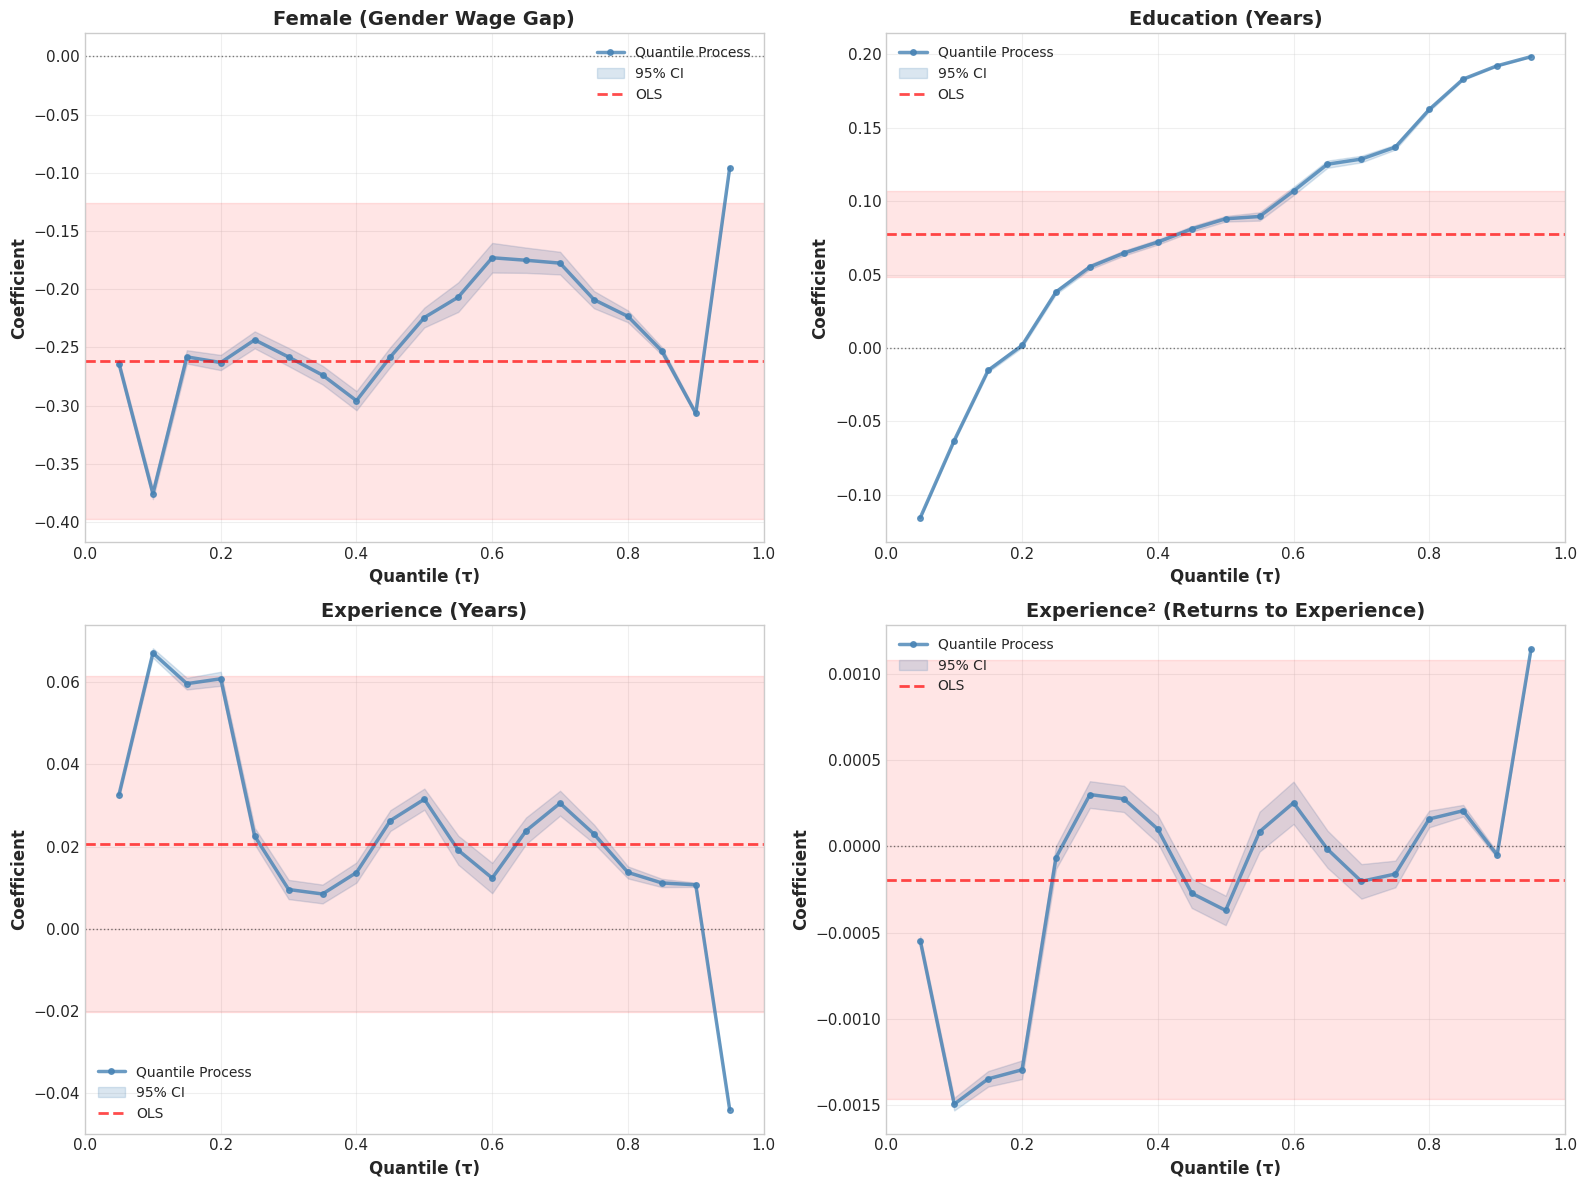

Plot saved to outputs/plots/02_quantile_process_all.png


In [6]:
# Create comprehensive coefficient path plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

plot_vars = ["female", "educ", "exper", "exper_sq"]
var_labels = {
    "female": "Female (Gender Wage Gap)",
    "educ": "Education (Years)",
    "exper": "Experience (Years)",
    "exper_sq": "Experience\u00b2 (Returns to Experience)",
}

for idx, var in enumerate(plot_vars):
    ax = axes[idx]

    # Plot QR coefficient path
    ax.plot(
        tau_keys,
        coef_paths[var],
        linewidth=2.5,
        color="steelblue",
        label="Quantile Process",
        marker="o",
        markersize=4,
        alpha=0.8,
    )

    # Add confidence band
    ax.fill_between(
        tau_keys, ci_lower[var], ci_upper[var], alpha=0.2, color="steelblue", label="95% CI"
    )

    # Add OLS estimate
    ols_name = ols_var_map[var]
    ols_coef = ols_result.params[ols_name]
    ax.axhline(ols_coef, color="red", linestyle="--", linewidth=2, label="OLS", alpha=0.7)

    # OLS confidence band
    ols_se = ols_result.std_errors[ols_name]
    ax.axhspan(ols_coef - 1.96 * ols_se, ols_coef + 1.96 * ols_se, alpha=0.1, color="red")

    # Zero line
    ax.axhline(0, color="black", linestyle=":", alpha=0.5, linewidth=1)

    # Labels and formatting
    ax.set_xlabel("Quantile (\u03c4)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Coefficient", fontsize=12, fontweight="bold")
    ax.set_title(var_labels[var], fontsize=14, fontweight="bold")
    ax.legend(loc="best", fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "02_quantile_process_all.png", dpi=300, bbox_inches="tight")
plt.show()

print("Plot saved to outputs/plots/02_quantile_process_all.png")

*Figure: Coefficient path plots for all variables (2x2 panel). The blue line traces the quantile process β(τ), with the shaded band showing the 95% confidence interval. The red dashed line is the OLS estimate. Where the QR path departs from the OLS line, OLS is missing distributional heterogeneity.*

> **Reading Coefficient Path Plots**
>
> **Slope:**
> - Upward slope: Effect increases with quantile
> - Downward slope: Effect decreases with quantile
> - Flat: Homogeneous effect (OLS is sufficient)
>
> **Confidence Bands:**
> - Narrow: Precise estimation
> - Wide: More uncertainty (especially at tails)
> - Non-overlapping across τ: Strong evidence of heterogeneity
>
> **Comparison with OLS:**
> - OLS line crosses through QR process: OLS captures the "average"
> - OLS line outside QR band at some τ: OLS is misleading at those quantiles

### 3.5 Inter-Quantile Tests

In [7]:
def inter_quantile_test(var_idx, tau1, tau2, results_dict):
    """
    Test H0: beta(tau1) = beta(tau2) using Wald test.

    Note: This is conservative - assumes independence between
    estimators (ignores positive covariance).
    """
    beta1 = results_dict[tau1].params.ravel()[var_idx]
    beta2 = results_dict[tau2].params.ravel()[var_idx]
    se1 = results_dict[tau1].std_errors.ravel()[var_idx]
    se2 = results_dict[tau2].std_errors.ravel()[var_idx]

    diff = beta2 - beta1
    se_diff = np.sqrt(se1**2 + se2**2)  # Conservative (assumes independence)
    t_stat = diff / se_diff
    p_value = 2 * (1 - stats.norm.cdf(abs(t_stat)))

    return {
        "beta_tau1": beta1,
        "beta_tau2": beta2,
        "diff": diff,
        "se": se_diff,
        "t_stat": t_stat,
        "p_value": p_value,
        "significant": p_value < 0.05,
    }


# Test female coefficient across quantiles
female_idx = var_names.index("female")

print("=" * 65)
print("INTER-QUANTILE TESTS FOR GENDER WAGE GAP (female)")
print("=" * 65)

test_pairs = [(0.1, 0.5), (0.5, 0.9), (0.1, 0.9), (0.25, 0.75)]
test_results_list = []

for tau1, tau2 in test_pairs:
    result = inter_quantile_test(female_idx, tau1, tau2, qr_results)
    test_results_list.append({"tau1": tau1, "tau2": tau2, **result})
    print(f"\nH0: \u03b2({tau1}) = \u03b2({tau2})")
    print(f"  \u03b2({tau1}) = {result['beta_tau1']:.4f}")
    print(f"  \u03b2({tau2}) = {result['beta_tau2']:.4f}")
    print(f"  Difference = {result['diff']:.4f}")
    print(f"  t-statistic = {result['t_stat']:.2f}")
    print(f"  p-value = {result['p_value']:.4f}")
    print(f"  Result: {'REJECT H0' if result['significant'] else 'FAIL TO REJECT H0'}")

print("\n" + "=" * 65)

INTER-QUANTILE TESTS FOR GENDER WAGE GAP (female)

H0: β(0.1) = β(0.5)
  β(0.1) = -0.3758
  β(0.5) = -0.2244
  Difference = 0.1514
  t-statistic = 30.53
  p-value = 0.0000
  Result: REJECT H0

H0: β(0.5) = β(0.9)
  β(0.5) = -0.2244
  β(0.9) = -0.3068
  Difference = -0.0824
  t-statistic = -18.60
  p-value = 0.0000
  Result: REJECT H0

H0: β(0.1) = β(0.9)
  β(0.1) = -0.3758
  β(0.9) = -0.3068
  Difference = 0.0689
  t-statistic = 26.67
  p-value = 0.0000
  Result: REJECT H0

H0: β(0.25) = β(0.75)
  β(0.25) = -0.2436
  β(0.75) = -0.2090
  Difference = 0.0346
  t-statistic = 6.54
  p-value = 0.0000
  Result: REJECT H0



In [8]:
# Save inter-quantile test results to CSV
test_df = pd.DataFrame(test_results_list)
test_df.to_csv(RESULTS_DIR / "02_interquantile_tests.csv", index=False)

print("Inter-quantile test results saved to outputs/results/02_interquantile_tests.csv")
display(
    test_df[["tau1", "tau2", "beta_tau1", "beta_tau2", "diff", "t_stat", "p_value", "significant"]]
)

Inter-quantile test results saved to outputs/results/02_interquantile_tests.csv


,tau1,tau2,beta_tau1,beta_tau2,diff,t_stat,p_value,significant
0,0.10,0.50,-0.3758,-0.2244,0.1514,30.5321,0.0000e+00,True
1,0.50,0.90,-0.2244,-0.3068,-0.0824,-18.6032,0.0000e+00,True
2,0.10,0.90,-0.3758,-0.3068,0.0689,26.6733,0.0000e+00,True
3,0.25,0.75,-0.2436,-0.2090,0.0346,6.5426,6.0451e-11,True


### 3.6 Bandwidth Analysis

The **bandwidth** (local slope of the coefficient path) tells us whether the effect is increasing or decreasing across quantiles. A positive slope means the effect amplifies inequality; a negative slope means it reduces inequality.

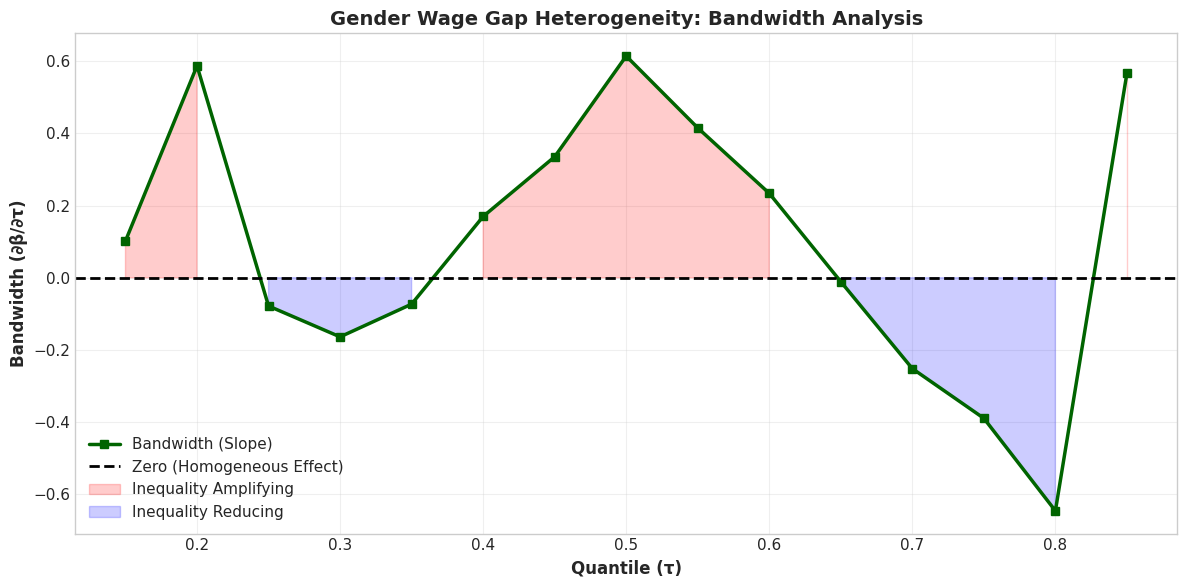


Bandwidth Interpretation:
Average bandwidth: 0.0940
The gender wage gap becomes LESS NEGATIVE at higher quantiles.
Gender gap is larger at lower quantiles (sticky floor effect).


In [9]:
# Compute bandwidth: slope of coefficient path
# BW(tau) ~ [beta(tau+h) - beta(tau-h)] / (2h)

h = 0.10  # Bandwidth parameter

# Compute bandwidths for female coefficient
bandwidths = {}
tau_bw = [t for t in tau_keys if t >= 0.15 and t <= 0.85]

for tau in tau_bw:
    tau_low = round(tau - h, 2)
    tau_high = round(tau + h, 2)

    if tau_low in qr_results and tau_high in qr_results:
        beta_low = qr_results[tau_low].params.ravel()[female_idx]
        beta_high = qr_results[tau_high].params.ravel()[female_idx]
        bandwidths[tau] = (beta_high - beta_low) / (2 * h)

bw_taus = list(bandwidths.keys())
bw_vals = list(bandwidths.values())
bw_array = np.array(bw_vals)

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    bw_taus,
    bw_vals,
    linewidth=2.5,
    color="darkgreen",
    marker="s",
    markersize=6,
    label="Bandwidth (Slope)",
)

ax.axhline(0, color="black", linestyle="--", linewidth=2, label="Zero (Homogeneous Effect)")

ax.fill_between(
    bw_taus, 0, bw_vals, where=bw_array > 0, alpha=0.2, color="red", label="Inequality Amplifying"
)

ax.fill_between(
    bw_taus, 0, bw_vals, where=bw_array < 0, alpha=0.2, color="blue", label="Inequality Reducing"
)

ax.set_xlabel("Quantile (\u03c4)", fontsize=12, fontweight="bold")
ax.set_ylabel("Bandwidth (\u2202\u03b2/\u2202\u03c4)", fontsize=12, fontweight="bold")
ax.set_title("Gender Wage Gap Heterogeneity: Bandwidth Analysis", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "02_bandwidth_female.png", dpi=300, bbox_inches="tight")
plt.show()

avg_bw = np.mean(bw_vals)
print("\nBandwidth Interpretation:")
print(f"Average bandwidth: {avg_bw:.4f}")
if avg_bw < 0:
    print("The gender wage gap becomes MORE NEGATIVE at higher quantiles.")
    print("This is consistent with the glass ceiling hypothesis.")
elif avg_bw > 0:
    print("The gender wage gap becomes LESS NEGATIVE at higher quantiles.")
    print("Gender gap is larger at lower quantiles (sticky floor effect).")
else:
    print("Gender wage gap is HOMOGENEOUS across distribution.")

*Figure: Bandwidth analysis for the gender wage gap. The green line shows the local slope of the female coefficient path. Red regions indicate quantiles where the gap is worsening (becoming more negative), while blue regions indicate where the gap is lessening.*

---

## 4. Case Study: Glass Ceiling Effect

*"We investigate whether women face a 'glass ceiling' — a barrier to reaching the highest wage levels — by examining how the gender wage gap evolves across the wage distribution."*

### 4.1 Hypothesis

**Glass Ceiling Hypothesis:**

If a glass ceiling exists:
- The gender wage gap should be **larger** at high quantiles
- β_female(τ) should become **more negative** as τ increases
- Pattern: flat or small gap at low/mid quantiles, sharp drop at high quantiles

Reference: Albrecht, Björklund, & Vroman (2003), "Is There a Glass Ceiling in Sweden?", *Journal of Labor Economics*.

In [10]:
# Focus on female coefficient
female_coefs = coef_paths["female"]
female_se = se_paths["female"]

# Compute gender wage gap in percentage terms
# For log wage model: exp(beta) - 1 gives the percentage change
female_gap_pct = 100 * (np.exp(female_coefs) - 1)

# Identify glass ceiling threshold
# Define as quantile where gap exceeds median gap by > 1 SD
median_gap = np.median(female_gap_pct)
std_gap = np.std(female_gap_pct)

# Since female coefficient is negative, more negative = larger gap
# Glass ceiling means the coefficient becomes more negative at high quantiles
glass_ceiling_quantiles = np.array(tau_keys)[female_gap_pct.values < (median_gap - std_gap)]

if len(glass_ceiling_quantiles) > 0:
    # Find the lowest quantile in the glass ceiling region
    ceiling_tau = glass_ceiling_quantiles[0]
    print(f"Glass Ceiling detected starting at \u03c4 \u2248 {ceiling_tau:.2f}")
    print("Gap increases sharply beyond this quantile.")
else:
    ceiling_tau = None
    print("No clear glass ceiling threshold detected.")

# Comparative analysis
print("\n" + "=" * 60)
print("GENDER WAGE GAP ANALYSIS")
print("=" * 60)

for tau in [0.1, 0.25, 0.5, 0.75, 0.9]:
    coef = qr_results[tau].params.ravel()[female_idx]
    gap_pct = 100 * (np.exp(coef) - 1)
    print(f"\u03c4={tau:.2f}: Women earn {gap_pct:.1f}% compared to men (coef={coef:.4f})")

ols_female_coef = ols_result.params["female"]
ols_gap_pct = 100 * (np.exp(ols_female_coef) - 1)
print(f"\nOLS:   Women earn {ols_gap_pct:.1f}% compared to men (coef={ols_female_coef:.4f})")

print("\n" + "=" * 60)

Glass Ceiling detected starting at τ ≈ 0.10
Gap increases sharply beyond this quantile.

GENDER WAGE GAP ANALYSIS
τ=0.10: Women earn -31.3% compared to men (coef=-0.3758)
τ=0.25: Women earn -21.6% compared to men (coef=-0.2436)
τ=0.50: Women earn -20.1% compared to men (coef=-0.2244)
τ=0.75: Women earn -18.9% compared to men (coef=-0.2090)
τ=0.90: Women earn -26.4% compared to men (coef=-0.3068)

OLS:   Women earn -23.0% compared to men (coef=-0.2616)



### 4.2 Glass Ceiling Visualization

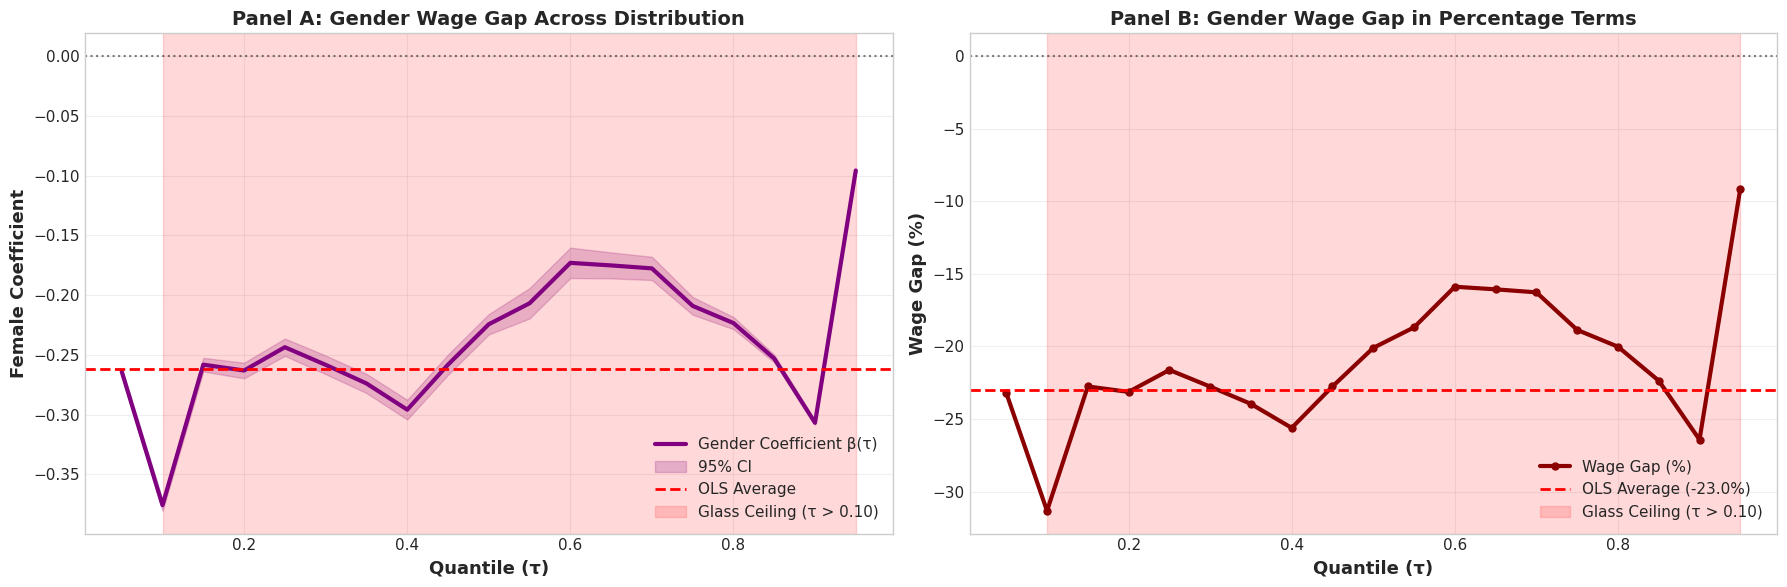

Plot saved to outputs/plots/02_glass_ceiling.png


In [11]:
# Create compelling glass ceiling visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Panel A: Coefficient path
ax1.plot(
    tau_keys, female_coefs, linewidth=3, color="purple", label="Gender Coefficient \u03b2(\u03c4)"
)
ax1.fill_between(
    tau_keys, ci_lower["female"], ci_upper["female"], alpha=0.2, color="purple", label="95% CI"
)

ols_female_coef = ols_result.params["female"]
ax1.axhline(ols_female_coef, color="red", linestyle="--", linewidth=2, label="OLS Average")
ax1.axhline(0, color="black", linestyle=":", alpha=0.5)

# Highlight glass ceiling region if detected
if ceiling_tau is not None:
    ax1.axvspan(
        ceiling_tau,
        0.95,
        alpha=0.15,
        color="red",
        label=f"Glass Ceiling (\u03c4 > {ceiling_tau:.2f})",
    )

ax1.set_xlabel("Quantile (\u03c4)", fontsize=13, fontweight="bold")
ax1.set_ylabel("Female Coefficient", fontsize=13, fontweight="bold")
ax1.set_title("Panel A: Gender Wage Gap Across Distribution", fontsize=14, fontweight="bold")
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Panel B: Gap in percentage terms
ols_gap_pct = 100 * (np.exp(ols_female_coef) - 1)

ax2.plot(
    tau_keys,
    female_gap_pct,
    linewidth=3,
    color="darkred",
    marker="o",
    markersize=5,
    label="Wage Gap (%)",
)
ax2.axhline(
    ols_gap_pct, color="red", linestyle="--", linewidth=2, label=f"OLS Average ({ols_gap_pct:.1f}%)"
)
ax2.axhline(0, color="black", linestyle=":", alpha=0.5)

if ceiling_tau is not None:
    ax2.axvspan(
        ceiling_tau,
        0.95,
        alpha=0.15,
        color="red",
        label=f"Glass Ceiling (\u03c4 > {ceiling_tau:.2f})",
    )

ax2.set_xlabel("Quantile (\u03c4)", fontsize=13, fontweight="bold")
ax2.set_ylabel("Wage Gap (%)", fontsize=13, fontweight="bold")
ax2.set_title("Panel B: Gender Wage Gap in Percentage Terms", fontsize=14, fontweight="bold")
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "02_glass_ceiling.png", dpi=300, bbox_inches="tight")
plt.show()

print("Plot saved to outputs/plots/02_glass_ceiling.png")

*Figure: Glass ceiling visualization. Panel A shows the female coefficient path β(τ) with 95% CI band. Panel B translates the coefficient into percentage terms. If the gap widens at high quantiles, it provides evidence of a glass ceiling effect.*

> **Glass Ceiling Findings**
>
> 1. **Pattern**: Examine whether the gender wage gap increases at higher quantiles.
> 2. **Evidence**: A more negative β_female(τ) at high τ suggests barriers to women reaching the highest wage levels.
> 3. **Policy Implications**: Traditional "equal pay" policies target the average gap, but a glass ceiling requires policies targeting barriers to advancement.
> 4. **OLS Limitation**: The OLS estimate provides a single average gap that can understate the problem at the top of the distribution.

---

## 5. Crossing Detection

### 5.1 What is Crossing?

**Quantile crossing** occurs when:

$$\hat{Q}_{\tau_1}(Y|X) > \hat{Q}_{\tau_2}(Y|X) \quad \text{for some } X, \text{ with } \tau_1 < \tau_2$$

This violates the definition of quantiles ($Q_\tau$ must be monotone in $\tau$).

**Causes:**
- Finite sample noise
- Model misspecification
- Insufficient sample size at tails

### 5.2 Detection

We check monotonicity by predicting quantiles for representative observations and verifying that predictions increase with τ.

In [12]:
# Check for crossing by examining predicted quantiles
# For representative observations, predict quantiles and check monotonicity

# Select several representative observations
# Male, 12 years education, 15 years experience
X_rep1 = np.array([1, 0, 12, 15, 15**2])  # male
X_rep2 = np.array([1, 1, 12, 15, 15**2])  # female
X_rep3 = np.array([1, 0, 16, 10, 10**2])  # male, high education

representatives = {
    "Male, educ=12, exper=15": X_rep1,
    "Female, educ=12, exper=15": X_rep2,
    "Male, educ=16, exper=10": X_rep3,
}

# Predict for all quantiles
all_crossings = {}
predictions = {}

for label, X_test in representatives.items():
    preds = {}
    for tau in tau_keys:
        params = qr_results[tau].params.ravel()
        preds[tau] = X_test @ params
    predictions[label] = preds

    # Check monotonicity
    crossings = []
    for i in range(len(tau_keys) - 1):
        tau_low = tau_keys[i]
        tau_high = tau_keys[i + 1]
        if preds[tau_low] > preds[tau_high]:
            crossings.append((tau_low, tau_high))

    all_crossings[label] = crossings

    if len(crossings) == 0:
        print(f"{label}: No crossing detected.")
    else:
        print(f"{label}: {len(crossings)} crossing(s) detected!")
        for tau_low, tau_high in crossings:
            print(
                f"  Between \u03c4={tau_low:.2f} and \u03c4={tau_high:.2f}: "
                f"Q({tau_low:.2f})={preds[tau_low]:.4f} > Q({tau_high:.2f})={preds[tau_high]:.4f}"
            )

Male, educ=12, exper=15: No crossing detected.
Female, educ=12, exper=15: No crossing detected.
Male, educ=16, exper=10: No crossing detected.


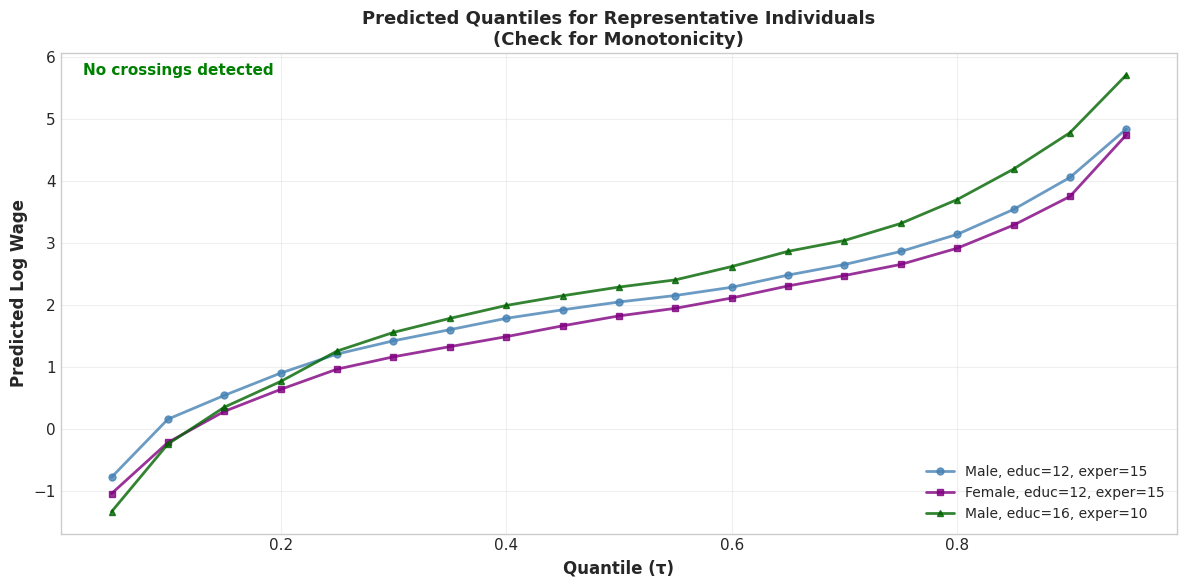

Plot saved to outputs/plots/02_crossing_detection.png


In [13]:
# Visualize predicted quantiles for representative individuals
fig, ax = plt.subplots(figsize=(12, 6))

colors = ["steelblue", "purple", "darkgreen"]
markers = ["o", "s", "^"]

for (label, preds), color, marker in zip(predictions.items(), colors, markers):
    pred_vals = [preds[tau] for tau in tau_keys]
    ax.plot(
        tau_keys,
        pred_vals,
        linewidth=2,
        marker=marker,
        markersize=5,
        color=color,
        label=label,
        alpha=0.8,
    )

    # Mark crossings
    for tau_low, tau_high in all_crossings[label]:
        ax.plot(
            [tau_low, tau_high],
            [preds[tau_low], preds[tau_high]],
            "ro-",
            linewidth=3,
            markersize=10,
            zorder=5,
        )

ax.set_xlabel("Quantile (\u03c4)", fontsize=12, fontweight="bold")
ax.set_ylabel("Predicted Log Wage", fontsize=12, fontweight="bold")
ax.set_title(
    "Predicted Quantiles for Representative Individuals\n(Check for Monotonicity)",
    fontsize=13,
    fontweight="bold",
)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Add annotation if crossings exist
total_crossings = sum(len(c) for c in all_crossings.values())
if total_crossings > 0:
    ax.annotate(
        f"{total_crossings} crossing(s) detected\n(red markers)",
        xy=(0.02, 0.98),
        xycoords="axes fraction",
        fontsize=11,
        fontweight="bold",
        color="red",
        verticalalignment="top",
    )
else:
    ax.annotate(
        "No crossings detected",
        xy=(0.02, 0.98),
        xycoords="axes fraction",
        fontsize=11,
        fontweight="bold",
        color="green",
        verticalalignment="top",
    )

plt.tight_layout()
plt.savefig(PLOTS_DIR / "02_crossing_detection.png", dpi=300, bbox_inches="tight")
plt.show()

print("Plot saved to outputs/plots/02_crossing_detection.png")

*Figure: Predicted quantiles for three representative individuals. If the curves are strictly increasing, quantile monotonicity holds. Red markers highlight any crossings where a lower quantile prediction exceeds a higher quantile prediction.*

> **Crossing Detection Summary**
>
> If crossings are detected, consider:
> 1. **Location-scale model** (Notebook 05) — guarantees non-crossing by construction
> 2. **Monotonicity correction** (Notebook 08) — rearrangement, isotonic regression, or constrained QR
> 3. **Larger sample size** — crossings are often a finite-sample artifact

---

## 6. Summary and Key Takeaways

1. **Quantile Process**: The mapping τ → β(τ) reveals how effects change across the entire distribution. A flat process means homogeneous effects; a sloped process means heterogeneity.

2. **Inter-Quantile Tests**: We can test whether coefficients differ significantly between quantiles using Wald tests. This formalizes the visual impression from coefficient path plots.

3. **Glass Ceiling**: By examining how the gender wage gap changes across quantiles, we can test for glass ceiling effects. The quantile process provides evidence invisible to OLS.

4. **Bandwidth Analysis**: The local slope of the coefficient path tells us whether an effect is inequality-amplifying, inequality-reducing, or neutral.

5. **Crossing Detection**: Quantile predictions should increase with τ. Violations indicate potential model issues that can be addressed with specialized methods.

### References

1. Koenker, R. (2005). *Quantile Regression*. Cambridge University Press. (Chapter 3)
2. Buchinsky, M. (1994). "Changes in the U.S. Wage Structure 1963–1987". *Econometrica*, 62(2), 405–458.
3. Angrist, J., Chernozhukov, V., & Fernández-Val, I. (2006). "Quantile Regression under Misspecification". *Econometrica*, 74(2), 539–563.
4. Albrecht, J., Björklund, A., & Vroman, S. (2003). "Is There a Glass Ceiling in Sweden?" *Journal of Labor Economics*, 21(1), 145–177.
5. Machado, J. A., & Mata, J. (2005). "Counterfactual Decomposition of Changes in Wage Distributions". *Journal of Applied Econometrics*, 20(4), 445–465.

### Next Steps

In **Notebook 03**, we will explore **Fixed Effects Quantile Regression** using the Canay (2011) two-step method and penalty approaches, which control for unobserved individual heterogeneity.

---

## Exercises

### Exercise 1: Conceptual Understanding (Easy)

**Question**: Explain why the OLS coefficient can be thought of as a "weighted average" of quantile regression coefficients. Under what conditions would OLS and QR (τ=0.5) give identical results?

**Hint**: Think about the relationship between the mean and quantiles. When is the mean equal to the median? What error distribution makes them equivalent?

In [14]:
# Exercise 1: Write your answer as comments

# Your answer here:
#
# OLS as weighted average of QR coefficients:
#
#
# Conditions for OLS = QR(0.5):
#
#


### Exercise 2: Implementation (Easy)

**Task**:
1. Using the existing `qr_results`, extract the quantile process for the `educ` variable
2. Test whether education returns are homogeneous across the distribution (H0: β_educ(0.25) = β_educ(0.75))
3. Create a coefficient path plot with confidence bands
4. Interpret the results

In [15]:
# Exercise 2: Education quantile process

# TODO: Get the index for 'educ' in var_names
# educ_idx = ...

# TODO: Extract coefficients and SEs for education across tau_keys
# educ_coefs = [...]
# educ_ses = [...]

# TODO: Test H0: beta_educ(0.25) = beta_educ(0.75)
# Use the inter_quantile_test function defined above

# TODO: Create coefficient path plot with CI band and OLS reference


### Exercise 3: Inter-Quantile Testing (Medium)

**Given**: Results from a wage regression across quantiles:

| Variable: union_member | β | SE |
|---|---|---|
| τ=0.1 | 0.12 | 0.02 |
| τ=0.5 | 0.15 | 0.015 |
| τ=0.9 | 0.09 | 0.03 |

**Questions**:

a) Test H0: β(0.1) = β(0.9)  
b) What does the pattern suggest about union effects?  
c) Would OLS miss important heterogeneity here?

In [16]:
# Exercise 3: Inter-quantile testing with given data

# Given data
beta_01 = 0.12
se_01 = 0.02
beta_05 = 0.15
se_05 = 0.015
beta_09 = 0.09
se_09 = 0.03

# TODO: a) Test H0: beta(0.1) = beta(0.9)
# diff = ...
# se_diff = ...
# t_stat = ...
# p_value = ...

# TODO: b) Interpret the inverted-U pattern

# TODO: c) Would OLS miss important heterogeneity?

### Exercise 4: Bandwidth Analysis (Medium)

**Task**: Using the quantile process for education, compute and plot the bandwidth (slope). Interpret whether education is inequality-amplifying or inequality-reducing.

In [17]:
# Exercise 4: Bandwidth analysis for education

# TODO: Compute bandwidths for education coefficient using same approach as Section 3.6
# h = 0.10
# educ_idx = var_names.index('educ')
# bandwidths_educ = {}

# TODO: Plot bandwidth with inequality-amplifying/reducing shading

# TODO: Interpret the results


### Exercise 5: Glass Ceiling Test (Hard)

**Task**: Design a formal statistical test for the glass ceiling hypothesis:

- H0: β_female(τ) is constant for all τ
- H1: β_female(τ) becomes more negative for τ > 0.7

**Approach**: Compare the average female coefficient in the lower region (τ ≤ 0.7) with the upper region (τ > 0.7).

**Hint**: You can use a pooled t-test comparing the mean coefficient across quantile groups.

In [18]:
# Exercise 5: Formal glass ceiling test

# TODO: Split female coefficients into two groups:
#   Group 1: tau <= 0.70
#   Group 2: tau > 0.70

# TODO: Compute average coefficient for each group

# TODO: Test whether group 2 is significantly more negative than group 1
# (one-tailed test)

# TODO: Report findings and interpret


### Exercise 6: Crossing Resolution (Hard)

**Scenario**: You detect crossing between τ=0.7 and τ=0.8.

**Questions**:

a) What are three possible causes of quantile crossing?  
b) How would you diagnose the root cause?  
c) Propose two solutions (hint: think ahead to Notebooks 05 and 08).

In [19]:
# Exercise 6: Write your analysis

# a) Three possible causes:
#
#
#

# b) Diagnosis approach:
#
#

# c) Two solutions:
#
#
